# Tracking Mangrove Loss in the Sundarbans (1988-2022) Using Landsat Data

## Introduction

Mangroves are one of the most important ecosystems, protecting coastal regions, supporting biodiversity, and acting as carbon sinks. However, due to deforestation, climate change, and human activities, they are rapidly disappearing.
In this beginner-friendly project, we analyze a dataset of annual mangrove maps (1988-2022) derived from Landsat satellite imagery. We will:

* Visualize the forest cover for different years

* Calculate the total mangrove loss between 1988 and 2022

* Track yearly deforestation trends using a cumulative loss approach

* This is a great introductory project for anyone interested in geospatial data analysis using Python!

### Step 1: Import important libraries

In [3]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt  
import rasterio
import os  

In [4]:
cd  "D:\Shailja Data\Input Files\sundarbans"

D:\Shailja Data\Input Files\sundarbans


### Step 2: Loading and Visualizing the Data

We first load the TIFF files corresponding to different years using rasterio and visualize the 1988 and 2022 maps to compare forest cover.

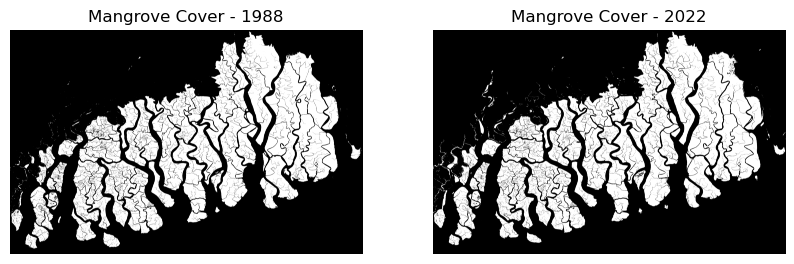

In [7]:
with rasterio.open("1988.tif") as src_1988, rasterio.open("2022.tif") as src_2022:
    forest_1988 = src_1988.read(1)
    forest_2022 = src_2022.read(1)

# Visualize 1988 vs 2022
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(forest_1988, cmap="gray")
ax[0].set_title("Mangrove Cover - 1988")
ax[0].axis("off")
ax[1].imshow(forest_2022, cmap="gray")
ax[1].set_title("Mangrove Cover - 2022")
ax[1].axis("off")
plt.show()

### Step 3: Understanding Pixel Area Calculation in GeoTIFF Data

When working with satellite imagery, each pixel represents a certain area on the Earth's surface. To estimate mangrove loss in square kilometers, we need to convert pixel values into real-world distances using metadata from the GeoTIFF files.

#### 1. Extracting Pixel Size from Metadata
Every GeoTIFF file has an Affine transform matrix that provides the spatial resolution of the image. Specifically:
* transform.a gives the pixel width in degrees (longitude)
* transform.e gives the pixel height in degrees (latitude)

#### 2. Converting Degrees to Meters
Since the Earth is not a perfect sphere, the conversion from degrees to meters varies with latitude:

Meters per degree longitude = 111320 * cos(latitude in radians) (varies with latitude)
Meters per degree latitude = 110574 (nearly constant)
For the Sundarbans region (~22.5° latitude), we calculate:

meters_per_degree_lon ≈ 111320 * cos(22.5°) ≈ 102840 m
meters_per_degree_lat ≈ 110574 m
Step 3: Calculating Area per Pixel
The area represented by each pixel is:
(Pixel Width × Meters per Degree Longitude) × (Pixel Height × Meters per Degree Latitude)/ 10^6
Pixel Area (km²)= (Pixel Width × Meters per Degree Longitude)×(Pixel Height×Meters per Degree Latitude)/10^6
 
This gives us the real-world area covered by each pixel in square kilometers, allowing us to quantify mangrove loss accurately.

This method ensures that we correctly interpret satellite data for environmental analysis. 🚀

### Step 4: Calculating the Total Forest Loss (1988-2022)

To measure how much mangrove forest was lost, we compare the pixel values from 1988 and 2022:

* Pixel Value 1 → Represents forest

* Pixel Value 0 → Represents non-forest

* Forest Loss → Pixels where 1988 had forest (1), but 2022 does not (0).

In [9]:
# Compute forest loss pixels
loss_pixels = (forest_1988 == 1) & (forest_2022 == 0)
total_loss_pixels = np.sum(loss_pixels)

# Convert pixel count to area
import math
transform = src_1988.transform
pixel_width_deg = abs(transform.a)
pixel_height_deg = abs(transform.e)
latitude = 22.5  # Approximate Sundarbans latitude
meters_per_degree_lon = 111320 * math.cos(math.radians(latitude))
meters_per_degree_lat = 110574
pixel_area_km2 = (pixel_width_deg * meters_per_degree_lon) * (pixel_height_deg * meters_per_degree_lat) / 1e6

total_forest_loss_km2 = total_loss_pixels * pixel_area_km2

# Print the result
print(f"Total lost pixels: {total_loss_pixels}")
print(f"Total mangrove loss (1988-2022): {total_forest_loss_km2:.2f} km²")

Total lost pixels: 324981
Total mangrove loss (1988-2022): 268.41 km²


### Step 5: Tracking Loss Year by Year

Instead of just comparing 1988 and 2022, we can track how much forest was lost each year.


Year 1989: Cumulative loss = 14.14 km²
Year 1990: Cumulative loss = 19.46 km²
Year 1991: Cumulative loss = 25.19 km²
Year 1992: Cumulative loss = 45.64 km²
Year 1993: Cumulative loss = 54.61 km²
Year 1994: Cumulative loss = 65.49 km²
Year 1995: Cumulative loss = 81.87 km²
Year 1996: Cumulative loss = 94.67 km²
Year 1997: Cumulative loss = 100.38 km²
Year 1998: Cumulative loss = 105.38 km²
Year 1999: Cumulative loss = 113.79 km²
Year 2000: Cumulative loss = 121.38 km²
Year 2001: Cumulative loss = 129.98 km²
Year 2002: Cumulative loss = 147.68 km²
Year 2003: Cumulative loss = 153.16 km²
Year 2004: Cumulative loss = 161.70 km²
Year 2005: Cumulative loss = 173.03 km²
Year 2006: Cumulative loss = 183.18 km²
Year 2007: Cumulative loss = 187.53 km²
Year 2008: Cumulative loss = 203.24 km²
Year 2009: Cumulative loss = 211.22 km²
Year 2010: Cumulative loss = 218.59 km²
Year 2011: Cumulative loss = 225.72 km²
Year 2012: Cumulative loss = 238.70 km²
Year 2013: Cumulative loss = 249.25 km²
Year 201

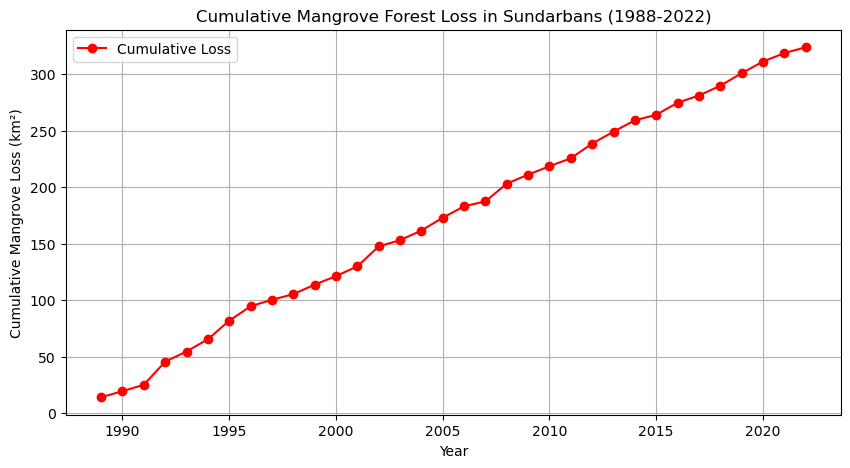

In [11]:

def get_pixel_area_km2(tif_file):
    with rasterio.open(tif_file) as src:
        transform = src.transform
    pixel_width_deg = abs(transform.a)
    pixel_height_deg = abs(transform.e)
    latitude = 22.5  # Approximate latitude for Sundarbans
    meters_per_degree_lon = 111320 * math.cos(math.radians(latitude))
    meters_per_degree_lat = 110574
    return (pixel_width_deg * meters_per_degree_lon) * (pixel_height_deg * meters_per_degree_lat) / 1e6

# Get pixel area from one reference file (1988)
pixel_area_km2 = get_pixel_area_km2("1988.tif")

# List years and initialize loss tracking
years = list(range(1988, 2023))
loss_per_year = []
cumulative_loss = 0

# Iterate over consecutive year pairs
for i in range(len(years) - 1):
    year1, year2 = years[i], years[i+1]
    
    with rasterio.open(f"{year1}.tif") as src1, rasterio.open(f"{year2}.tif") as src2:
        forest1 = src1.read(1)
        forest2 = src2.read(1)
    
    # Calculate loss for this year
    loss_pixels = (forest1 == 1) & (forest2 == 0)
    yearly_loss = np.sum(loss_pixels) * pixel_area_km2
    cumulative_loss += yearly_loss
    
    # Store results
    loss_per_year.append((year2, cumulative_loss))
    print(f"Year {year2}: Cumulative loss = {cumulative_loss:.2f} km²")

# Extract years and loss values for plotting
years_plot, loss_values = zip(*loss_per_year)

# Plot cumulative loss
plt.figure(figsize=(10, 5))
plt.plot(years_plot, loss_values, marker='o', linestyle='-', color='red', label="Cumulative Loss")
plt.xlabel("Year")
plt.ylabel("Cumulative Mangrove Loss (km²)")
plt.title("Cumulative Mangrove Forest Loss in Sundarbans (1988-2022)")
plt.grid(True)
plt.legend()
plt.show()



Why does the cumulative loss exceed the net loss?

* Forests don’t just disappear permanently—they may recover over time.

* Some areas might lose forest one year and regain it later.

* Tracking the cumulative loss allows us to see the yearly impact of deforestation events.

## Conclusion

Conclusion

In this project, we:

* Loaded and visualized annual mangrove maps (1988-2022).
* Calculated total mangrove loss between 1988 and 2022 (~X km²).
* Tracked yearly deforestation trends and plotted a cumulative loss graph.

This approach helps us understand long-term forest loss and the impact of conservation efforts.